In [44]:
from TradingviewData import TradingViewData,Interval
import pandas as pd
import numpy as np

request = TradingViewData()

In [3]:
request.search('METAL','MCX')

Expecting value: line 1 column 1 (char 0)


[]

In [4]:
coin_types = {
    'bitcoin': 'BTCUSD',
    'etherum': 'ETHUSD',
    'ripple': 'XRPUSD',
    'solana': 'SOLUSD',
    'dogecoin': 'DOGEUSD',
    'cardano': 'ADAUSD',
    'shibaInu': 'SHIBUSD',
    'polkadot': 'DOTUSD',
    'aave': 'AAVEUSD',
    'stellar': 'XLMUSD'
}

coin_data = {}
for coin_type, symb in coin_types.items():
    coin = request.get_hist(symbol=symb,exchange='CRYPTO',interval=Interval.daily,n_bars=1470)
    coin_data[coin_type] = coin

In [26]:
n_days = coin_data["bitcoin"].index.max()-coin_data["bitcoin"].index.min()

In [48]:
coin_dates = {}

coin_data["bitcoin"]["month"]=list(coin_data["bitcoin"].index.month)
years = range(2021, 2026) 
months = range(1, 13) 

for coin_type in coin_types.keys():

    df_empty = pd.DataFrame(index=years, columns=months)

    coin_data[coin_type]["year"]=list(coin_data[coin_type].index.year)
    coin_data[coin_type]["month"]=list(coin_data[coin_type].index.month)
    
    counts = coin_data[coin_type].groupby(["year", "month"]).count()["symbol"].values
    missing_values = 60 - len(counts)

    counts_padded = np.pad(counts, (0, missing_values), mode='constant', constant_values=0)
    reshaped_counts = counts_padded.reshape(len(years), len(months))

    df_empty[:] = reshaped_counts
    coin_dates[coin_type] = df_empty

coin_dates["bitcoin"]

,1,2,3,4,5,6,7,8,9,10,11,12
2021,11,28,31,30,31,30,31,31,30,31,30,31
2022,31,28,31,30,31,30,31,31,30,31,30,31
2023,31,28,31,30,31,30,31,31,30,31,30,31
2024,31,29,31,30,31,30,31,31,30,31,30,31
2025,29,0,0,0,0,0,0,0,0,0,0,0


In [69]:
for coinT in coin_types:
    coin = request.get_hist(symbol=coin_types[coinT],exchange='CRYPTO',interval=Interval.daily,n_bars=1470)
    coin["year"]=coin.index.year
    coin["month"]=coin.index.month
    coin["day"]=coin.index.day
    coin[coin["year"]==2025].to_csv(f"2025/{coin_types[coinT]}.csv",index=False)

In [5]:
relience_data = request.get_hist(symbol='RELIANCE',exchange='NSE',interval=Interval.min_5,n_bars=5000)

relience_data

,symbol,open,high,low,close,volume
datetime,,,,,,
2024-10-22 08:50:00,NSE:RELIANCE,1361.375,1362.30,1360.550,1361.150,87858.0
2024-10-22 08:55:00,NSE:RELIANCE,1361.150,1361.15,1358.400,1358.775,112716.0
2024-10-22 09:00:00,NSE:RELIANCE,1358.775,1359.50,1357.550,1359.350,139616.0
2024-10-22 09:05:00,NSE:RELIANCE,1359.075,1359.30,1356.825,1357.475,102386.0
2024-10-22 09:10:00,NSE:RELIANCE,1357.475,1357.50,1355.500,1355.800,195288.0
...,...,...,...,...,...,...
2025-01-28 10:35:00,NSE:RELIANCE,1231.950,1235.00,1230.500,1235.000,225964.0
2025-01-28 10:40:00,NSE:RELIANCE,1234.900,1236.35,1234.200,1235.650,288009.0
2025-01-28 10:45:00,NSE:RELIANCE,1235.200,1235.90,1234.200,1234.350,184934.0


In [6]:
crudeoil_data = request.get_hist(symbol='MCXMETLDEX',exchange='MCX',interval=Interval.hour_1,n_bars=5000)

crudeoil_data

ERROR:TradingviewData.main:Connection timed out
ERROR:TradingviewData.main:no data, please check the exchange and symbol


<Axes: >

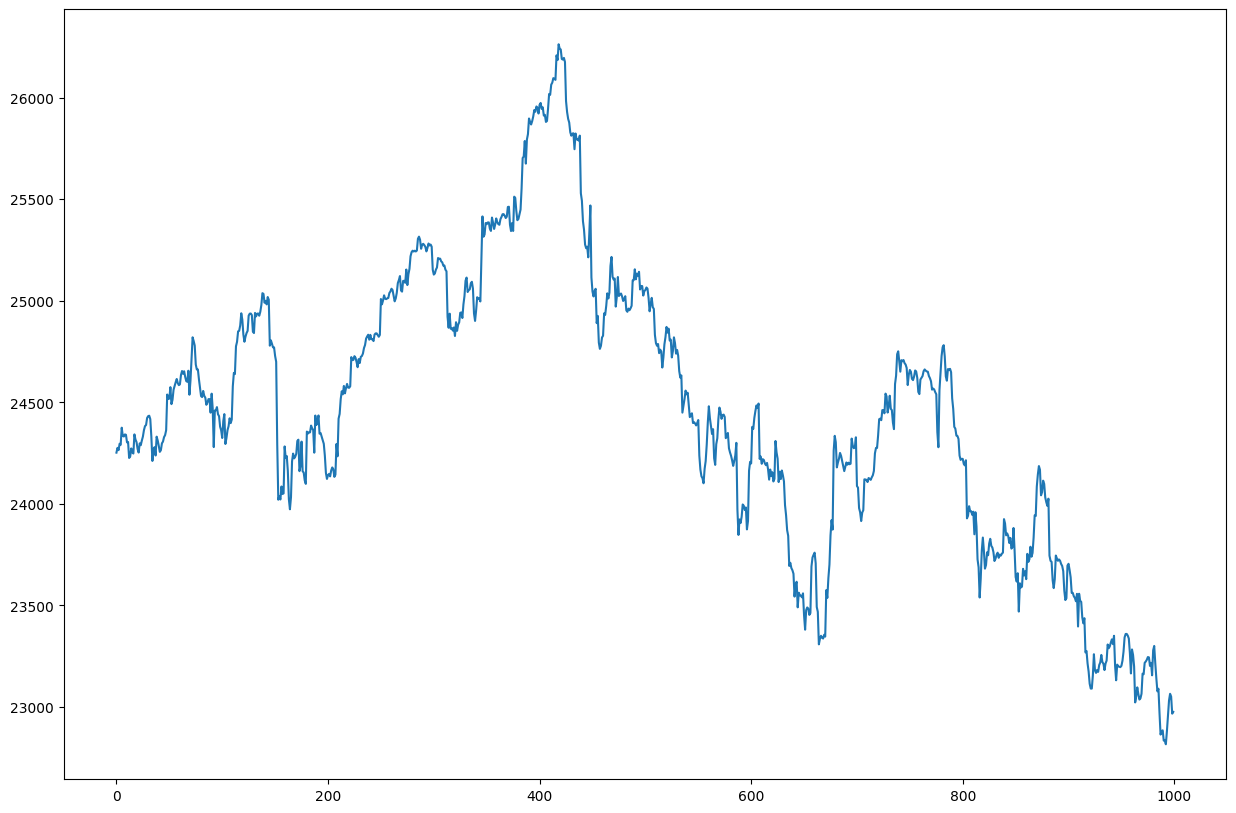

In [7]:
nifty_data.close.plot(figsize=(15,10),use_index=False)